In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error

ratings = pd.read_csv('../data/ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)

n = len(ratings_sorted)
train_end = int(0.7 * n)
val_end = int(0.8 * n)
train_df = ratings_sorted.iloc[:train_end].copy()
val_df = ratings_sorted.iloc[train_end:val_end].copy()
test_df = ratings_sorted.iloc[val_end:].copy()
global_mean = train_df['rating'].mean()

genre_cols = ['unknown','Action','Adventure','Animation','Children','Comedy','Crime','Documentary','Drama','Fantasy','Film-Noir','Horror','Musical','Mystery',
              'Romance','Sci-Fi','Thriller','War','Western']
item_cols = ['item_id','title','release_date','video_date','imdb_url'] + genre_cols

movies = pd.read_csv('../data/ml-100k/u.item', sep='|', names=item_cols, encoding='latin-1')
movies[genre_cols] = movies[genre_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

print(f'Фильмов: {len(movies)}')
print(movies[['item_id','title','release_date'] + genre_cols[:5]].head())

Фильмов: 1682
   item_id              title release_date  unknown  Action  Adventure  \
0        1   Toy Story (1995)  01-Jan-1995        0       0          0   
1        2   GoldenEye (1995)  01-Jan-1995        0       1          1   
2        3  Four Rooms (1995)  01-Jan-1995        0       0          0   
3        4  Get Shorty (1995)  01-Jan-1995        0       1          0   
4        5     Copycat (1995)  01-Jan-1995        0       0          0   

   Animation  Children  
0          1         1  
1          0         0  
2          0         0  
3          0         0  
4          0         0  


# Feature engineering

In [5]:
movies['year'] = pd.to_datetime(movies['release_date'], format='%d-%b-%Y', errors='coerce').dt.year
movies['year'] = movies['year'].fillna(movies['year'].median())

print(movies[['title', 'year']].head())
print(f'Диапозон годов: {movies['year'].min():.0f} - {movies['year'].max():.0f}')

               title    year
0   Toy Story (1995)  1995.0
1   GoldenEye (1995)  1995.0
2  Four Rooms (1995)  1995.0
3  Get Shorty (1995)  1995.0
4     Copycat (1995)  1995.0
Диапозон годов: 1922 - 1998


In [6]:
item_stats = train_df.groupby('item_id')['rating'].agg(['mean', 'count'])
item_stats.columns = ['item_mean_rating', 'item_popularity']

user_stats = train_df.groupby('user_id')['rating'].agg(['mean', 'count'])
user_stats.columns = ['user_mean_rating', 'user_activity']

item_stats['item_popularity_log'] = np.log1p(item_stats['item_popularity']) # моя идея логарифмирования из EDA
user_stats['user_activity_log'] = np.log1p(user_stats['user_activity'])

print(item_stats.head())
print(user_stats.head())

         item_mean_rating  item_popularity  item_popularity_log
item_id                                                        
1                3.906433              342             5.837730
2                3.301075               93             4.543295
3                3.027778               72             4.290459
4                3.506579              152             5.030438
5                3.323077               65             4.189655
         user_mean_rating  user_activity  user_activity_log
user_id                                                    
1                3.596838            253           5.537334
5                2.874286            175           5.170484
6                3.635071            211           5.356586
8                3.796610             59           4.094345
9                4.272727             22           3.135494


In [7]:
print(movies[genre_cols].dtypes.unique())

[dtype('int64')]


In [8]:
train_with_genres = train_df.merge(movies[['item_id']+ genre_cols], on='item_id', how='left')
genre_mean_rating = {}

for g in genre_cols:
    mask = train_with_genres[g] == 1
    genre_mean_rating[g] = train_with_genres.loc[mask, 'rating'].mean() if mask.sum() > 0 else global_mean
genre_mean_rating = pd.Series(genre_mean_rating)

def expected_rating_by_genres(row):
    active = [g for g in genre_cols if row[g] == 1]
    return np.mean([genre_mean_rating[g] for g in active]) if active else global_mean

movies['genre_expected_rating'] = movies.apply(expected_rating_by_genres, axis=1)

print(genre_mean_rating.sort_values(ascending=False).round(3))
print(movies[['title', 'genre_expected_rating']].head())

Film-Noir      3.907
War            3.825
Drama          3.691
Documentary    3.666
Crime          3.656
Mystery        3.647
Romance        3.637
Western        3.593
Sci-Fi         3.580
Animation      3.573
Thriller       3.520
Musical        3.514
Adventure      3.503
Action         3.493
Comedy         3.399
Children       3.329
Horror         3.269
Fantasy        3.215
unknown        3.200
dtype: float64
               title  genre_expected_rating
0   Toy Story (1995)               3.433443
1   GoldenEye (1995)               3.505383
2  Four Rooms (1995)               3.520093
3  Get Shorty (1995)               3.527566
4     Copycat (1995)               3.622515


In [9]:
year_median = movies['year'].median()

print(f"global_mean = {global_mean:.4f}")
print(f"year_median = {year_median:.0f}")

global_mean = 3.5300
year_median = 1995


Теперь заполним информацию о пользователях с помощью таблицы u.user

In [10]:
user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv('../data/ml-100k/u.user', sep='|', names=user_cols, encoding='latin-1')

print(users.head())
print(f'Професий: {users['occupation'].nunique()}')

users['gender_M'] = (users['gender'] == 'M').astype(int)
occ_dummies = pd.get_dummies(users['occupation'], prefix='occ').astype(int)
users = pd.concat([users, occ_dummies], axis=1)

demo_cols = ['age', 'gender_M'] + list(occ_dummies.columns)

users_features = users[['user_id'] + demo_cols]
print("Демо-признаков:", len(demo_cols))
print(users_features.head())

   user_id  age gender  occupation zip_code
0        1   24      M  technician    85711
1        2   53      F       other    94043
2        3   23      M      writer    32067
3        4   24      M  technician    43537
4        5   33      F       other    15213
Професий: 21
Демо-признаков: 23
   user_id  age  gender_M  occ_administrator  occ_artist  occ_doctor  \
0        1   24         1                  0           0           0   
1        2   53         0                  0           0           0   
2        3   23         1                  0           0           0   
3        4   24         1                  0           0           0   
4        5   33         0                  0           0           0   

   occ_educator  occ_engineer  occ_entertainment  occ_executive  ...  \
0             0             0                  0              0  ...   
1             0             0                  0              0  ...   
2             0             0                  0       

In [11]:
def build_features(df):
    d = df.merge(movies[['item_id', 'year', 'genre_expected_rating']+ genre_cols], on='item_id', how='left')
    d = d.merge(item_stats, on='item_id', how='left')
    d = d.merge(user_stats, on='user_id', how='left')
    d = d.merge(users_features, on='user_id', how='left')

    d['item_mean_rating'] = d['item_mean_rating'].fillna(d['genre_expected_rating']).fillna(global_mean)
    d['user_mean_rating'] = d['user_mean_rating'].fillna(global_mean)

    for col in ['item_popularity', 'user_activity', 'item_popularity_log', 'user_activity_log']:
        d[col] = d[col].fillna(0)

    d['year'] = d['year'].fillna(year_median)
    for g in genre_cols:
        d[g] = d[g].fillna(0)

    d['age'] = d['age'].fillna(users['age'].median())
    d['gender_M'] = d['gender_M'].fillna(0)

    for c in occ_dummies.columns:
        d[c] = d[c].fillna(0)

    feature_cols = (genre_cols + ['year', 'item_mean_rating', 'user_mean_rating',
                                 'item_popularity_log', 'user_activity_log'] + demo_cols)
    X = d[feature_cols].astype(float)
    y = d['rating'].astype(float)
    return X, y

X_train, y_train = build_features(train_df)
X_val, y_val = build_features(val_df)
X_test, y_test = build_features(test_df)


print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print(X_train.head())

assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
print("Пропусков нет")

X_train: (70000, 47) | X_val: (10000, 47) | X_test: (20000, 47)
   unknown  Action  Adventure  Animation  Children  Comedy  Crime  \
0      0.0     0.0        0.0        0.0       0.0     1.0    0.0   
1      0.0     0.0        0.0        0.0       0.0     0.0    0.0   
2      0.0     1.0        0.0        0.0       0.0     0.0    0.0   
3      0.0     0.0        0.0        0.0       0.0     0.0    0.0   
4      0.0     1.0        1.0        0.0       0.0     1.0    0.0   

   Documentary  Drama  Fantasy  ...  occ_marketing  occ_none  occ_other  \
0          0.0    0.0      0.0  ...            0.0       0.0        0.0   
1          0.0    1.0      0.0  ...            0.0       0.0        0.0   
2          0.0    0.0      0.0  ...            0.0       0.0        0.0   
3          0.0    0.0      0.0  ...            0.0       0.0        0.0   
4          0.0    0.0      0.0  ...            0.0       0.0        0.0   

   occ_programmer  occ_retired  occ_salesman  occ_scientist  occ_stude

Первая модель Ridge

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

def rmse_of(model, X, y):
    return root_mean_squared_error(y, model.predict(X))

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for a in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=a))])
    pipe.fit(X_train, y_train)
    train_rmse = rmse_of(pipe, X_train, y_train)
    val_rmse = rmse_of(pipe, X_val, y_val)
    results.append({'alpha': a, 'train_rmse': train_rmse, 'val_rmse': val_rmse})
    print(f"alpha={a:>7}:  train={train_rmse:.4f}   val={val_rmse:.4f}")

results_df = pd.DataFrame(results)
best_alpha = results_df.loc[results_df['val_rmse'].idxmin(), 'alpha']
print(f"\nЛучший alpha по val: {best_alpha}")

ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha))])
ridge_pipe.fit(X_train, y_train)

ridge_test_rmse = rmse_of(ridge_pipe, X_test, y_test)
print(f"Ridge TEST RMSE: {ridge_test_rmse:.4f}")
print(f"Item mean baseline: 1.0367")
print(f"Улучшение: {1.0367 - ridge_test_rmse:+.4f}")

alpha=   0.01:  train=0.9250   val=1.0279
alpha=    0.1:  train=0.9250   val=1.0279
alpha=    1.0:  train=0.9250   val=1.0279
alpha=   10.0:  train=0.9250   val=1.0279
alpha=  100.0:  train=0.9250   val=1.0278

Лучший alpha по val: 100.0
Ridge TEST RMSE: 1.0507
Item mean baseline: 1.0367
Улучшение: -0.0140


**Регуляризация не улучшила результат**, потому что модель не переобучалась (признаков мало относительно объёма данных) - L2 проявился бы сильнее при большом числе признаков или малой выборке. Однако главное что **разрыв между результатами train - val - test уменьшился по сравнению с CF - моделями**, это значит что **feature engineering сработал** и проблема новых пользователей в тестовой выборке начала сжиматься

Посмотрим какие признаки самые информативные

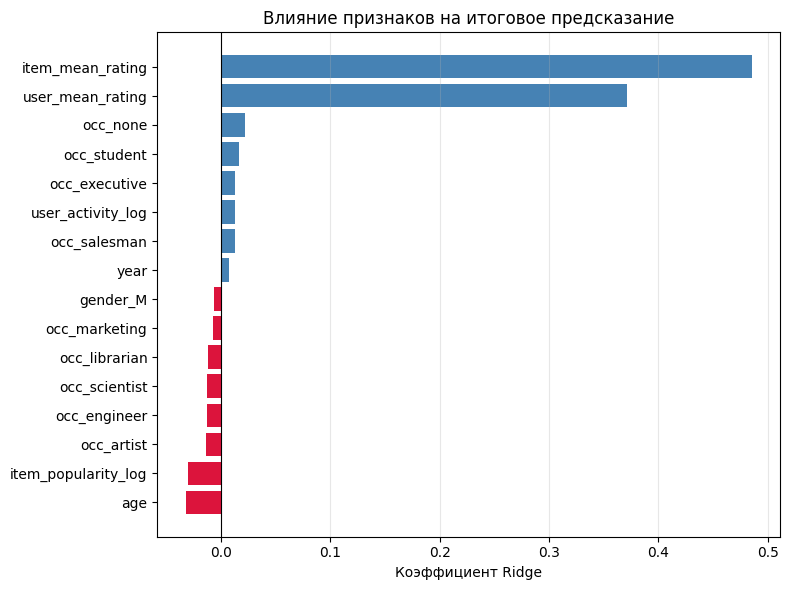

In [13]:
feature_cols = X_train.columns.tolist()
ridge = ridge_pipe.named_steps['ridge']
coefs = pd.Series(ridge.coef_, index=feature_cols).sort_values()

import matplotlib.pyplot as plt
top = pd.concat([coefs.head(8), coefs.tail(8)])
colors = ['crimson' if v < 0 else 'steelblue' for v in top.values]

plt.figure(figsize=(8, 6))
plt.barh(top.index, top.values, color=colors)
plt.xlabel('Коэффициент Ridge')
plt.title('Влияние признаков на итоговое предсказание')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Модель держится на item_mean_rating и user_mean_rating; остальные признаки, включая демографию, имеют коэффициенты около нуля и содержательно почти не влияют. Интерпретировать их знаки по отдельности рискованно из-за коллинеарности - для честной оценки важности лучше SHAP, который учитывает взаимодействия

Построим матрицу корреляции для признаков

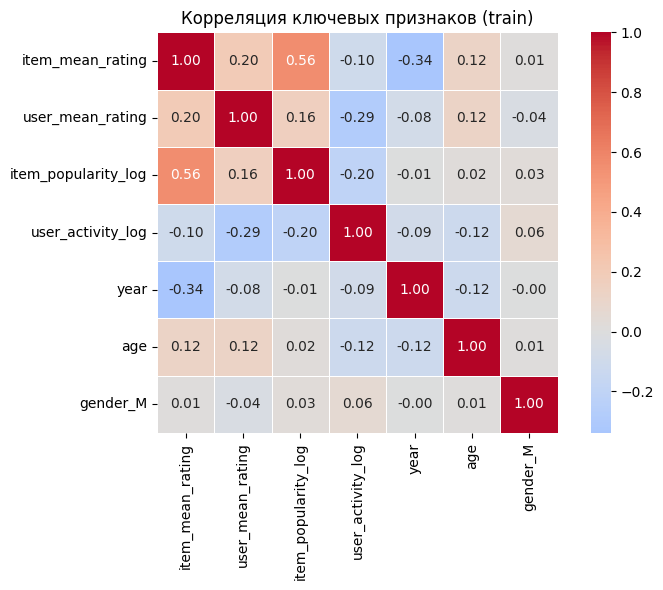

In [14]:
import seaborn as sns

key_features = ['item_mean_rating', 'user_mean_rating', 'item_popularity_log','user_activity_log', 'year', 'age', 'gender_M']
corr = X_train[key_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Корреляция ключевых признаков (train)')
plt.tight_layout()
plt.show()

Единственная заметная корреляция - item_mean_rating и item_popularity_log (0.56): популярные фильмы оценены выше. Это объясняет отрицательный коэффициент популярности в Ridge - при коллинеарности признаки делят влияние, и знак менее важного «переворачивается». Остальные признаки слабо коррелированы (|r| < 0.35); демография практически независима от рейтинга (|r| ≤ 0.12), что согласуется с её околонулевыми весами в модели линейной регрессии. Мультиколлинеарность (кроме указанной пары) отсутствует, поэтому коэффициенты Ridge интерпретируемы. Для tree-based моделей коллинеарность некритична - они устойчивы к ней. Перейдём именно к ним.

**Random Forest**

In [15]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb

rf_grid = [{'n_estimators' : 200, 'max_depth' : 10},
           {'n_estimators' : 200, 'max_depth' : 15},
           {'n_estimators' : 300, 'max_depth' : 20}]

rf_results = []
for p in rf_grid:
    rf = RandomForestRegressor(random_state=42, n_jobs=-1, **p)
    rf.fit(X_train, y_train)
    tr = root_mean_squared_error(y_train, rf.predict(X_train))
    va = root_mean_squared_error(y_val, rf.predict(X_val))
    rf_results.append({**p, 'train': tr, 'val': va})
    print(f"RF {p} -> train={tr:.4f} val={va:.4f}")

rf_best = pd.DataFrame(rf_results).sort_values('val').iloc[0]
print("RF best:", dict(rf_best), "\n")

RF {'n_estimators': 200, 'max_depth': 10} -> train=0.8654 val=1.0365
RF {'n_estimators': 200, 'max_depth': 15} -> train=0.7086 val=1.0549
RF {'n_estimators': 300, 'max_depth': 20} -> train=0.5154 val=1.0651
RF best: {'n_estimators': np.float64(200.0), 'max_depth': np.float64(10.0), 'train': np.float64(0.8653831427899348), 'val': np.float64(1.036530764270671)} 



**Gradient Boosting**

In [16]:
param_grid = [
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03},
]

gb_results = []
for params in param_grid:
    gb = GradientBoostingRegressor(random_state=42, **params)
    gb.fit(X_train, y_train)
    train_rmse_gb = root_mean_squared_error(y_train, gb.predict(X_train))
    val_rmse_gb = root_mean_squared_error(y_val, gb.predict(X_val))
    gb_results.append({**params, 'train_rmse': train_rmse_gb, 'val_rmse': val_rmse_gb})
    print(f"{params}  ->  train={train_rmse_gb:.4f}  val={val_rmse_gb:.4f}")

gb_best = pd.DataFrame(gb_results).sort_values('val_rmse').iloc[0]
print("GB best:", dict(gb_best), "\n")

{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}  ->  train=0.9132  val=1.0345
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}  ->  train=0.9071  val=1.0743
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}  ->  train=0.9135  val=1.0389
{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}  ->  train=0.8982  val=1.0817
{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}  ->  train=0.8923  val=1.0873
{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03}  ->  train=0.8942  val=1.0816
GB best: {'n_estimators': np.float64(100.0), 'max_depth': np.float64(3.0), 'learning_rate': np.float64(0.1), 'train_rmse': np.float64(0.9132020456888776), 'val_rmse': np.float64(1.0344723755870173)} 



**LightGBM**

In [17]:
lgb_grid = [
    {'num_leaves': 15,  'learning_rate': 0.05, 'n_estimators': 500},
    {'num_leaves': 31,  'learning_rate': 0.05, 'n_estimators': 500},
    {'num_leaves': 31,  'learning_rate': 0.03, 'n_estimators': 1000},
    {'num_leaves': 63,  'learning_rate': 0.03, 'n_estimators': 1000},
]
lgb_results = []

for p in lgb_grid:
    model = lgb.LGBMRegressor(random_state=42, **p)
    model.fit( X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse', callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
    train_rmse_lgb = root_mean_squared_error(y_train, model.predict(X_train))
    val_rmse_lgb = root_mean_squared_error(y_val, model.predict(X_val))
    lgb_results.append({**p, 'best_iter': model.best_iteration_, 'train': train_rmse_lgb, 'val': val_rmse_lgb})
    print(f"LGB {p} -> train={train_rmse_lgb:.4f} val={val_rmse_lgb:.4f} (best_iter={model.best_iteration_})")

lgb_best = pd.DataFrame(lgb_results).sort_values('val').iloc[0]
print("LGB best:", dict(lgb_best), "\n")


C:\Users\asus\AppData\Roaming\Python\Python314\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1175
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 46
[LightGBM] [Info] Start training from score 3.530043
LGB {'num_leaves': 15, 'learning_rate': 0.05, 'n_estimators': 500} -> train=0.9204 val=1.0214 (best_iter=51)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1175
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 46
[LightGBM] [Info] Start training from score 3.530043


C:\Users\asus\AppData\Roaming\Python\Python314\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LGB {'num_leaves': 31, 'learning_rate': 0.05, 'n_estimators': 500} -> train=0.9190 val=1.0288 (best_iter=40)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1175
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 46
[LightGBM] [Info] Start training from score 3.530043


C:\Users\asus\AppData\Roaming\Python\Python314\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LGB {'num_leaves': 31, 'learning_rate': 0.03, 'n_estimators': 1000} -> train=0.9266 val=1.0284 (best_iter=54)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1175
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 46
[LightGBM] [Info] Start training from score 3.530043


C:\Users\asus\AppData\Roaming\Python\Python314\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LGB {'num_leaves': 63, 'learning_rate': 0.03, 'n_estimators': 1000} -> train=0.9140 val=1.0362 (best_iter=60)
LGB best: {'num_leaves': np.float64(15.0), 'learning_rate': np.float64(0.05), 'n_estimators': np.float64(500.0), 'best_iter': np.float64(51.0), 'train': np.float64(0.9204265944541005), 'val': np.float64(1.021438881851408)} 



In [18]:
print("RF best:", dict(rf_best))
print("GB best:", dict(gb_best))
print("LGB best:", dict(lgb_best))

RF best: {'n_estimators': np.float64(200.0), 'max_depth': np.float64(10.0), 'train': np.float64(0.8653831427899348), 'val': np.float64(1.036530764270671)}
GB best: {'n_estimators': np.float64(100.0), 'max_depth': np.float64(3.0), 'learning_rate': np.float64(0.1), 'train_rmse': np.float64(0.9132020456888776), 'val_rmse': np.float64(1.0344723755870173)}
LGB best: {'num_leaves': np.float64(15.0), 'learning_rate': np.float64(0.05), 'n_estimators': np.float64(500.0), 'best_iter': np.float64(51.0), 'train': np.float64(0.9204265944541005), 'val': np.float64(1.021438881851408)}


In [19]:
rf_final = RandomForestRegressor(
    random_state=42, n_jobs=-1,
    n_estimators=int(rf_best['n_estimators']),
    max_depth=int(rf_best['max_depth'])
)
rf_final.fit(X_train, y_train)
rf_test = root_mean_squared_error(y_test, rf_final.predict(X_test))

gb_final = GradientBoostingRegressor(
    random_state=42,
    n_estimators=int(gb_best['n_estimators']),
    max_depth=int(gb_best['max_depth']),
    learning_rate=gb_best['learning_rate']
)
gb_final.fit(X_train, y_train)
gb_test = root_mean_squared_error(y_test, gb_final.predict(X_test))

lgb_final = lgb.LGBMRegressor(
    random_state=42, n_jobs=-1, verbose=-1,
    num_leaves=int(lgb_best['num_leaves']),
    learning_rate=lgb_best['learning_rate'],
    n_estimators=int(lgb_best['best_iter'])
)
lgb_final.fit(X_train, y_train)
lgb_test = root_mean_squared_error(y_test, lgb_final.predict(X_test))

summary = pd.DataFrame([
    {'model': 'Item mean baseline', 'val_rmse': None, 'test_rmse': 1.0367},
    {'model': 'Ridge (linear)', 'val_rmse': 1.0278, 'test_rmse': ridge_test_rmse},
    {'model': 'RandomForest', 'val_rmse': float(rf_best['val']),  'test_rmse': rf_test},
    {'model': 'GradientBoosting', 'val_rmse': float(gb_best['val_rmse']), 'test_rmse': gb_test},
    {'model': 'LightGBM', 'val_rmse': float(lgb_best['val']), 'test_rmse': lgb_test},
    ]).sort_values('test_rmse')

print(summary.to_string(index=False))

             model  val_rmse  test_rmse
Item mean baseline       NaN   1.036700
          LightGBM  1.021439   1.040003
  GradientBoosting  1.034472   1.043653
    Ridge (linear)  1.027800   1.050660
      RandomForest  1.036531   1.052575


In [20]:
X_train_2 = X_train[['item_mean_rating', 'user_mean_rating']]
X_val_2   = X_val[['item_mean_rating', 'user_mean_rating']]
X_test_2  = X_test[['item_mean_rating', 'user_mean_rating']]

lgb_2 = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1,
                          num_leaves=15, learning_rate=0.05, n_estimators=51)
lgb_2.fit(X_train_2, y_train)
print("LGB 2 признака, test RMSE:", root_mean_squared_error(y_test, lgb_2.predict(X_test_2)))
print("LGB все признаки, test RMSE:", lgb_test)

LGB 2 признака, test RMSE: 1.0399586831230838
LGB все признаки, test RMSE: 1.040003237265232


Остальные 45 признаков не добавляют предсказательной силы на общем тесте - весь сигнал сосредоточен в item_mean_rating и user_mean_rating.

Попробуем сравнить модель с item_based только на тех пользователях, которые есть и в трейн и в тест выборках, чтобы понять лучше ли модель константы если у неё есть данные о пользователях

In [21]:
train_users = set(train_df['user_id'].unique())
train_items = set(train_df['item_id'].unique())

te = test_df.copy().reset_index(drop=True)
te['user_warm'] = te['user_id'].isin(train_users)
te['item_warm'] = te['item_id'].isin(train_items)
ww = (te['user_warm'] & te['item_warm']).values

y_arr = y_test.values
pred_lgb = lgb_final.predict(X_test)

pred_baseline = X_test['item_mean_rating'].values

print(f"=== Warm user + warm item (n={ww.sum()}, {ww.mean()*100:.1f}% теста) ===")
print(f"LightGBM: {root_mean_squared_error(y_arr[ww], pred_lgb[ww]):.4f}")
print(f"Item mean: {root_mean_squared_error(y_arr[ww], pred_baseline[ww]):.4f}")

=== Warm user + warm item (n=2286, 11.4% теста) ===
LightGBM: 1.0840
Item mean: 1.0580


In [22]:
print("X_test строк:", len(X_test), "| test_df строк:", len(test_df))
print("Индексы X_test совпадают с y_test", X_test.index.equals(y_test.index))

te_check = test_df.reset_index(drop=True)
X_check = X_test.reset_index(drop=True)
print(te_check['item_id'].head().tolist())
print(X_check['item_mean_rating'].head().tolist())

X_test строк: 20000 | test_df строк: 20000
Индексы X_test совпадают с y_test True
[322, 335, 323, 325, 264]
[3.097902097902098, 2.857142857142857, 2.968944099378882, 2.6344086021505375, 2.647887323943662]


При temporal split пары юзер-фильм, которые есть и в трейне и в тесте - это поздние оценки давних пользователей. Их исторические средние (user_mean_rating), посчитанные на раннем train, устаревают из-за дрейфа предпочтений, поэтому content-based модель, опирающаяся на них, проигрывает даже простому item-mean baseline. Это показывает, что при разбиении по времени свежесть признаков важнее их количества, и мотивирует признаки с временным затуханием (recency-weighting).


Теперь разберёмся с важностью признаков для lightGBM через shap

In [23]:
import shap
explainer = shap.TreeExplainer(lgb_final)

X_shap = X_val.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_shap)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 47)


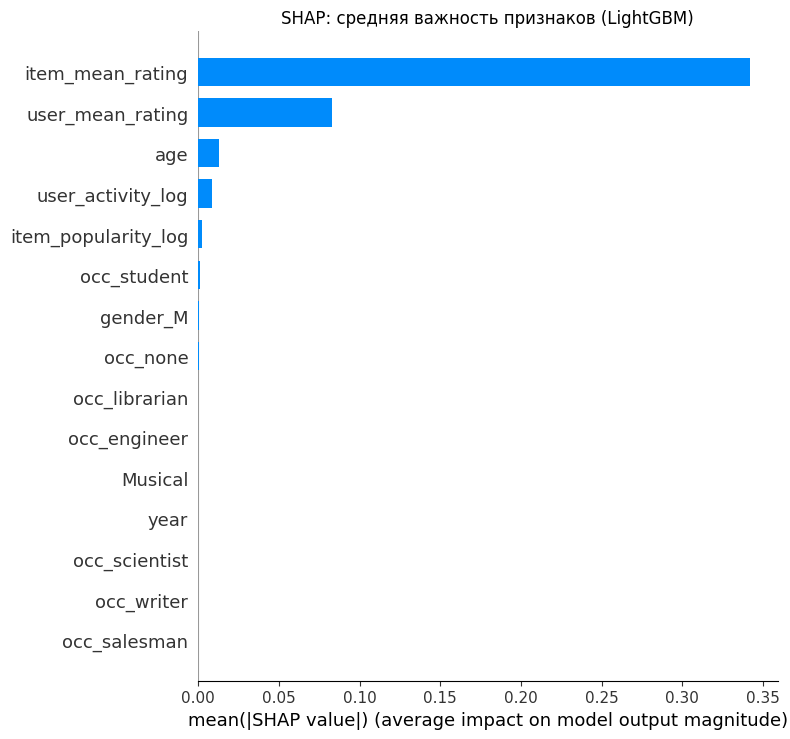

In [24]:
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('SHAP: средняя важность признаков (LightGBM)')
plt.tight_layout()
plt.savefig('../images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

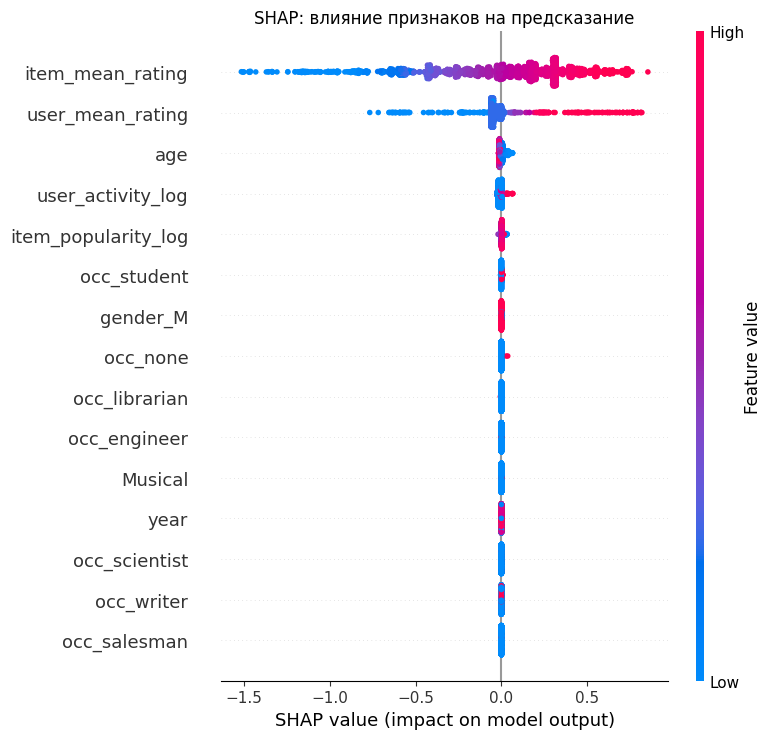

In [25]:
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('SHAP: влияние признаков на предсказание')
plt.tight_layout()
plt.show()

SHAP подтвердил, что предсказание почти полностью определяется двумя признаками - item_mean_rating (доминирует) и user_mean_rating. Оба показывают ожидаемое направление: высокий средний рейтинг фильма/юзера повышает предсказание. Демографические и жанровые признаки имеют околонулевой вклад, что согласуется с экспериментом "2 признака ≈ 47". Исключение - age: LightGBM обнаружил слабый нелинейный сигнал, невидимый линейной модели, но его величина недостаточна для влияния на RMSE. Вывод: на данном наборе признаков потолок качества задаётся историческими средними, а контентные признаки решают лишь item cold start, не улучшая предсказание на общем тесте.

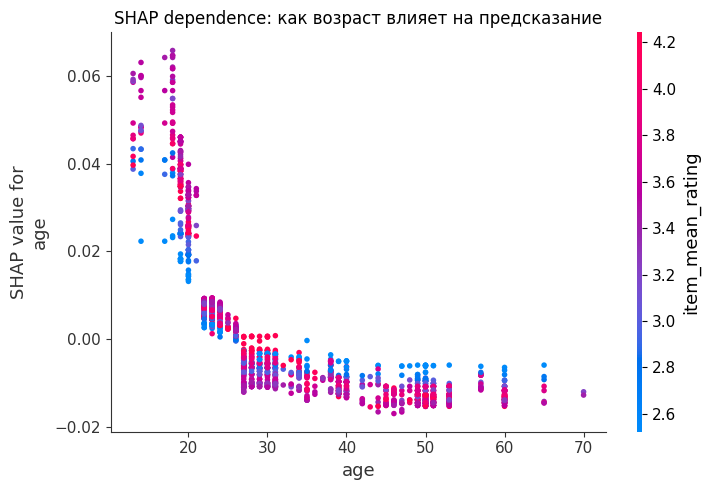

In [26]:
shap.dependence_plot('age', shap_values, X_shap, show=False)
plt.title('SHAP dependence: как возраст влияет на предсказание')
plt.tight_layout()
plt.show()

SHAP dependence для возраста выявил чёткую нелинейную зависимость: молодые пользователи (< 25) получают положительный вклад в предсказание (ставят выше среднего), после чего эффект резко падает и стабилизируется. Линейная модель этот сигнал теряет (околонулевой коэффициент), а LightGBM улавливает - конкретный пример преимущества нелинейной модели. Однако абсолютная величина вклада (+-0.06 балла) на два порядка меньше вклада исторических средних, поэтому на RMSE он не влияет. Демографический сигнал реален и интерпретируем, но недостаточен для практического улучшения.

**Wide & Deep**

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)
X_train_t = torch.tensor(X_train.values, dtype=torch.float)
y_train_t = torch.tensor(y_train.values, dtype=torch.float).unsqueeze(1)
X_val_t = torch.tensor(X_val.values, dtype=torch.float)
y_val_t = torch.tensor(y_val.values, dtype=torch.float).unsqueeze(1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float)
y_test_t = torch.tensor(y_test.values, dtype=torch.float).unsqueeze(1)

n_features = X_train_t.shape[1]

feat_mean = X_train_t.mean(dim=0, keepdim=True)
feat_std  = X_train_t.std(dim=0, keepdim=True) + 1e-8
X_train_t = (X_train_t - feat_mean) / feat_std
X_val_t   = (X_val_t   - feat_mean) / feat_std
X_test_t  = (X_test_t  - feat_mean) / feat_std

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

In [28]:
class WideAndDeep(nn.Module):
    def __init__(self, n_features, hidden=[64, 32], dropout = 0.2):
        super().__init__()
        self.wide = nn.Linear(n_features, 1)

        layers = []
        prev = n_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.deep = nn.Sequential(*layers)

    def forward(self, x):
        return self.wide(x) + self.deep(x)

model = WideAndDeep(n_features)
print(model)

WideAndDeep(
  (wide): Linear(in_features=47, out_features=1, bias=True)
  (deep): Sequential(
    (0): Linear(in_features=47, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [29]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

n_epochs = 100
patience = 10
best_state = None
epochs_no_improve = 0
history = {'train_rmse': [], 'val_rmse': []}
best_val = float('inf')

for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        loss = criterion(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_rmse = criterion(model(X_train_t), y_train_t).item() ** 0.5
        val_rmse = criterion(model(X_val_t), y_val_t).item() ** 0.5
    history['train_rmse'].append(train_rmse)
    history['val_rmse'].append(val_rmse)

    if val_rmse < best_val:
        best_val = val_rmse
        epochs_no_improve = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epoch % 5 == 0:
        print(f"epoch {epoch:3d}: train={train_rmse:.4f}  val={val_rmse:.4f}")

    if epochs_no_improve >= patience:
        print(f"Early stopping на эпохе {epoch} (лучший val={best_val:.4f})")
        break

model.load_state_dict(best_state)    

epoch   0: train=0.9868  val=1.2175
epoch   5: train=0.9228  val=1.1851
epoch  10: train=0.9191  val=1.1803
epoch  15: train=0.9147  val=1.1465
epoch  20: train=0.9140  val=1.1165
epoch  25: train=0.9148  val=1.0859
epoch  30: train=0.9136  val=1.1124
epoch  35: train=0.9133  val=1.0946
Early stopping на эпохе 38 (лучший val=1.0778)


<All keys matched successfully>

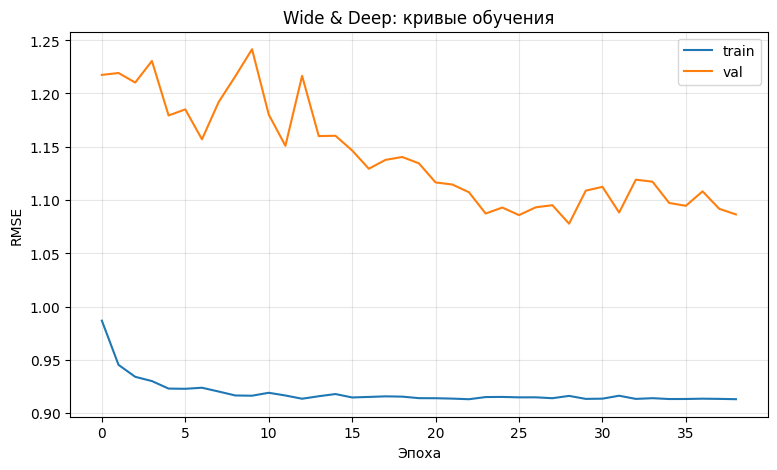

Wide & Deep TEST RMSE: 1.0615
LightGBM TEST RMSE:    1.0400
Item mean baseline:    1.0367


In [34]:
plt.figure(figsize=(9, 5))
plt.plot(history['train_rmse'], label='train')
plt.plot(history['val_rmse'],   label='val')
plt.xlabel('Эпоха')
plt.ylabel('RMSE')
plt.title('Wide & Deep: кривые обучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../images/wide_deep_training.png', dpi=150, bbox_inches='tight')
plt.show()

model.eval()
with torch.no_grad():
    wd_test = criterion(model(X_test_t), y_test_t).sqrt().item()
print(f"Wide & Deep TEST RMSE: {wd_test:.4f}")
print(f"LightGBM TEST RMSE:    {lgb_test:.4f}")
print(f"Item mean baseline:    1.0367")

In [31]:
model.eval()
with torch.no_grad():
    wd_test = criterion(model(X_test_t), y_test_t).item() ** 0.5
print(f"Wide & Deep TEST RMSE: {wd_test:.4f}")
print(f"LightGBM TEST RMSE:    {lgb_test:.4f}")
print(f"Item mean baseline:    1.0367")

Wide & Deep TEST RMSE: 1.0615
LightGBM TEST RMSE:    1.0400
Item mean baseline:    1.0367


In [32]:
final_summary = pd.DataFrame([
    {'model': 'Item mean baseline', 'test_rmse': 1.0367},
    {'model': 'LightGBM',           'test_rmse': lgb_test},
    {'model': 'GradientBoosting',   'test_rmse': gb_test},
    {'model': 'Ridge (linear)',     'test_rmse': ridge_test_rmse},
    {'model': 'RandomForest',       'test_rmse': rf_test},
    {'model': 'Wide & Deep',        'test_rmse': wd_test},
]).sort_values('test_rmse').reset_index(drop=True)

print(final_summary.to_string(index=False))

             model  test_rmse
Item mean baseline   1.036700
          LightGBM   1.040003
  GradientBoosting   1.043653
    Ridge (linear)   1.050660
      RandomForest   1.052575
       Wide & Deep   1.061491


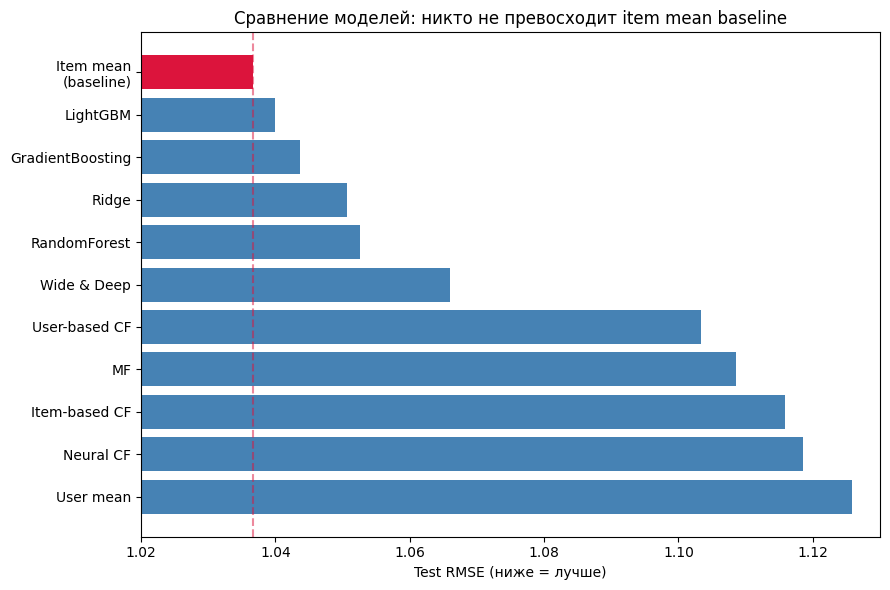

In [33]:
import matplotlib.pyplot as plt

models = ['User mean', 'Neural CF', 'Item-based CF', 'MF', 'User-based CF',
          'Wide & Deep', 'RandomForest', 'Ridge', 'GradientBoosting',
          'LightGBM', 'Item mean\n(baseline)']
rmse = [1.1258, 1.1185, 1.1158, 1.1085, 1.1034,
        1.0660, 1.0526, 1.0507, 1.0437, 1.0400, 1.0367]
colors = ['crimson' if m.startswith('Item mean') else 'steelblue' for m in models]

plt.figure(figsize=(9, 6))
plt.barh(models, rmse, color=colors)
plt.axvline(1.0367, color='crimson', linestyle='--', alpha=0.5)
plt.xlabel('Test RMSE (ниже = лучше)')
plt.title('Сравнение моделей: никто не превосходит item mean baseline')
plt.xlim(1.02, 1.13)
plt.tight_layout()
plt.savefig('../images/rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Выводы по ноутбуку 06 (Content-based модели)

**Цель ноутбука:** построить content-based подход, работающий на признаках (жанры, год, демография, исторические средние), чтобы решить cold start - проблему, на которой откатывались CF/MF из ноутбуков 03–05.

### Результаты моделей (test RMSE)

| Модель | Test RMSE |
|---|---|
| Item mean baseline | 1.0367 |
| LightGBM | 1.0400 |
| GradientBoosting | 1.0437 |
| Ridge (linear) | 1.0507 |
| RandomForest | 1.0526 |
| Wide & Deep | 1.0660 |

### Ключевые выводы

**1. Ни одна модель не превзошла простой item-mean baseline на общем тесте.** Разрывы минимальны (лучшая модель отстаёт на ~0.003). Причина не в качестве моделей, а в структуре данных: при temporal split ~80% тестовых пользователей новые (user cold start), и для них все модели откатываются к предсказанию, близкому к среднему по фильму - то есть к тому, что baseline уже делает. 

**2. Сложность модели не улучшает результат - на этих данных даже вредит.** Самая простая модель (baseline) оказалась лучшей, самая сложная (Wide & Deep) = худшей, с явным переобучением (train RMSE 0.89 против val 1.08). Это подтверждает известный факт: на табличных данных с малым числом информативных признаков gradient boosting превосходит нейросети, а линейные/константные baseline трудно побить.

**3. Практически весь предсказательный сигнал сосредоточен в двух признаках** - `item_mean_rating` и `user_mean_rating`. Доказано тремя независимыми способами: анализом коэффициентов и корреляций, значениями SHAP, и прямым экспериментом (LightGBM на 2 признаках даёт 1.03996 против 1.04000 на всех 47). Демографические и жанровые признаки почти не влияют на общий RMSE.

**4. Content-признаки решают item cold start, но не user cold start.** Жанры и год известны для нового фильма без единой оценки, поэтому item cold start смягчается (жанровое заполнение `item_mean_rating`). Но у пользователя нет контентного описания вкуса - демография (возраст, пол, профессия) оказалась слишком слабым сигналом, чтобы заменить историю оценок. Это фундаментальная асимметрия: фильм можно описать признаками, пользователя - нет.

**5. SHAP выявил слабый нелинейный эффект возраста**, невидимый линейной модели: молодые пользователи (< 25) склонны ставить оценки выше, после чего эффект стабилизируется. LightGBM его улавливает, Ridge = нет (околонулевые коэффициент). Конкретный пример преимущества нелинейной модели, хотя величина эффекта (+-0.06 балла) слишком мала, чтобы влиять на метрику.


### Общий вывод

Основное узкое место рекомендаций на MovieLens при честном temporal split - не мощность модели, а **cold start и дрейф предпочтений в данных**. Простые baseline трудно превзойти, потому что главный сигнал (среднее по фильму) они уже используют, а для новых пользователей информации структурно недостаточно. Общий RMSE-— малоинформативная метрика для этой задачи: она усредняет холодные и тёплые случаи и маскирует поведение модели на подгруппах. Это мотивирует переход к ранжирующим метрикам (Precision@K, NDCG) в ноутбуке 07, а также подходы с временным затуханием признаков и сбором данных о пользователе при онбординге как единственный реальный способ смягчить user cold start.